Selected image: C:\Users\hites\ML PHASE II\fashion-dataset\images\54068.jpg
Article Type: Casual Shoes


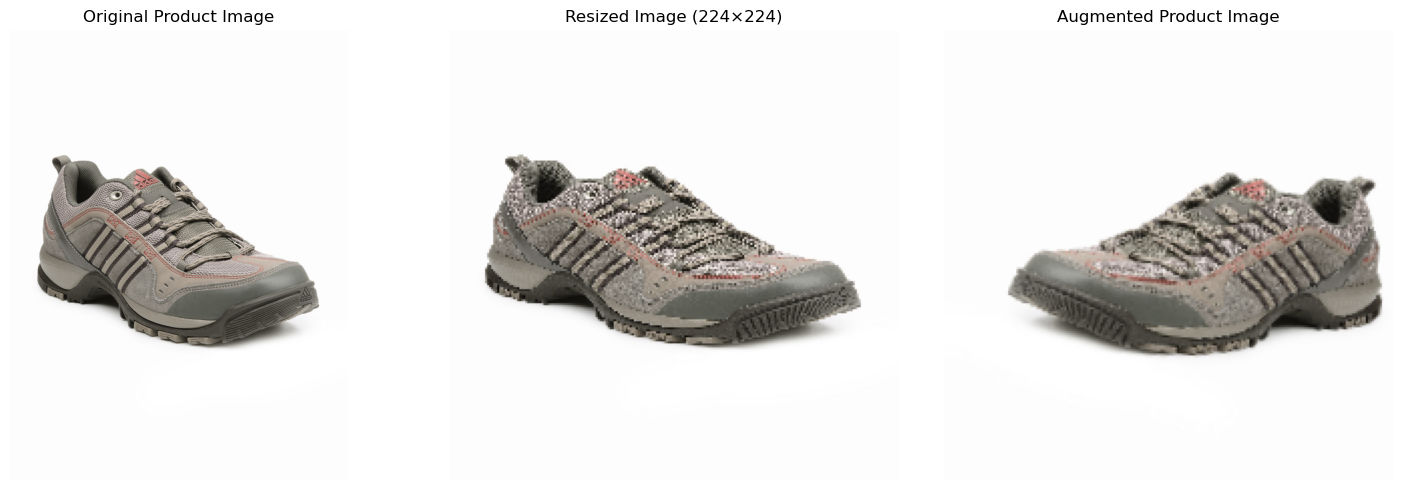

Saved: fashion_project_outputs/figures\preprocessing_examples.png


In [1]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
IMAGE_DIR = r"C:\Users\hites\ML PHASE II\fashion-dataset\images"
STYLES_CSV = r"C:\Users\hites\ML PHASE III\styles.csv"

SAVE_DIR = "fashion_project_outputs/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Load metadata
df = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
df["id"] = df["id"].astype(str)
df["image_path"] = df["id"].apply(lambda x: os.path.join(IMAGE_DIR, x + ".jpg"))

# Keep only existing image files
df = df[df["image_path"].apply(os.path.exists)].copy()

# Choose non-human product categories
product_only_classes = [
    "Watches",
    "Sports Shoes",
    "Casual Shoes",
    "Handbags",
    "Wallets",
    "Belts",
    "Sunglasses"
]

df_product = df[df["articleType"].isin(product_only_classes)].copy()

# Select one image
sample = df_product.sample(1, random_state=42).iloc[0]
image_path = sample["image_path"]

print("Selected image:", image_path)
print("Article Type:", sample["articleType"])

# Load images
original = load_img(image_path)
resized = load_img(image_path, target_size=(224, 224))

# Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

img_array = img_to_array(resized)
img_array = np.expand_dims(img_array, axis=0)

augmented = next(datagen.flow(img_array, batch_size=1))[0].astype("uint8")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title("Original Product Image")
axes[0].axis("off")

axes[1].imshow(resized)
axes[1].set_title("Resized Image (224×224)")
axes[1].axis("off")

axes[2].imshow(augmented)
axes[2].set_title("Augmented Product Image")
axes[2].axis("off")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "preprocessing_examples.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)